<a href="https://colab.research.google.com/github/JooshuaAnd/bikeshare_storytelling/blob/main/bikeshare_72230617.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
%matplotlib inline

In [ ]:
plt.rcParams['figure.figsize'] = [20.0, 7.0]
plt.rcParams.update({'font.size': 22})

sns.set_style('whitegrid')
sns.set_context('talk')

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/contactprad/bike-share-daily-data/bike_sharing_daily.csv')

In [ ]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
corr = df.select_dtypes(include=np.number).corr()

corr

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,0.412224,0.866025,0.496702,0.016145,-0.000016,-0.004337,-0.021477,0.150580,0.152638,0.016375,-0.112620,0.275255,0.659623,0.628830
season,0.412224,1.000000,-0.001844,0.831440,-0.010537,-0.003080,0.012485,0.019211,0.334315,0.342876,0.205445,-0.229046,0.210399,0.411623,0.406100
yr,0.866025,-0.001844,1.000000,-0.001792,0.007954,-0.005461,-0.002013,-0.048727,0.047604,0.046106,-0.110651,-0.011817,0.248546,0.594248,0.566710
mnth,0.496702,0.831440,-0.001792,1.000000,0.019191,0.009509,-0.005901,0.043528,0.220205,0.227459,0.222204,-0.207502,0.123006,0.293488,0.279977
holiday,0.016145,-0.010537,0.007954,0.019191,1.000000,-0.101960,-0.253023,-0.034627,-0.028556,-0.032507,-0.015937,0.006292,0.054274,-0.108745,-0.068348
weekday,-0.000016,-0.003080,-0.005461,0.009509,-0.101960,1.000000,0.035790,0.031087,-0.000170,-0.007537,-0.052232,0.014282,0.059923,0.057367,0.067443
workingday,-0.004337,0.012485,-0.002013,-0.005901,-0.253023,0.035790,1.000000,0.061200,0.052660,0.052182,0.024327,-0.018796,-0.518044,0.303907,0.061156
weathersit,-0.021477,0.019211,-0.048727,0.043528,-0.034627,0.031087,0.061200,1.000000,-0.120602,-0.121583,0.591045,0.039511,-0.247353,-0.260388,-0.297391
temp,0.150580,0.334315,0.047604,0.220205,-0.028556,-0.000170,0.052660,-0.120602,1.000000,0.991702,0.126963,-0.157944,0.543285,0.540012,0.627494
atemp,0.152638,0.342876,0.046106,0.227459,-0.032507,-0.007537,0.052182,-0.121583,0.991702,1.000000,0.139988,-0.183643,0.543864,0.544192,0.631066


In [ ]:
#rename columns
df = df.rename(columns={'dteday':'datetime',
                        'yr':'year',
                        'mnth':'month',
                        'weathersit':'weather',
                        'hum':'humidity',
                        'cnt':'total_rides'})

#set categorical variables
##why set as categories??
df['season'] = df['season'].astype('category')
df['year'] = df['year'].astype('category')
df['month'] = df['month'].astype('category')
df['holiday'] = df['holiday'].astype('category')
df['weekday'] = df['weekday'].astype('category')
df['workingday'] = df['workingday'].astype('category')
df['weather'] = df['weather'].astype('category')

In [ ]:
df.head()

,instant,datetime,season,year,month,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total_rides
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
print('Winter vs Spring')
print(ttest_ind(df.total_rides[df['season'] == 1], df.total_rides[df['season'] == 2]))
print('Winter vs Summer')
print(ttest_ind(df.total_rides[df['season'] == 1], df.total_rides[df['season'] == 3]))
print('Winter vs Fall')
print(ttest_ind(df.total_rides[df['season'] == 1], df.total_rides[df['season'] == 4]))
print('Spring vs Fall')
print(ttest_ind(df.total_rides[df['season'] == 2], df.total_rides[df['season'] == 4]))
print('Spring vs Summer')
print(ttest_ind(df.total_rides[df['season'] == 2], df.total_rides[df['season'] == 3]))
print('Summer vs Fall')
print(ttest_ind(df.total_rides[df['season'] == 3], df.total_rides[df['season'] == 4]))

Winter vs Spring
TtestResult(statistic=np.float64(-14.65873026929708), pvalue=np.float64(1.5284822271363832e-38), df=np.float64(363.0))
Winter vs Summer
TtestResult(statistic=np.float64(-20.40505135948835), pvalue=np.float64(2.134072968524431e-62), df=np.float64(367.0))
Winter vs Fall
TtestResult(statistic=np.float64(-12.933694332032188), pvalue=np.float64(1.2022067175230552e-31), df=np.float64(357.0))
Spring vs Fall
TtestResult(statistic=np.float64(1.4800205959906783), pvalue=np.float64(0.13974231789501404), df=np.float64(360.0))
Spring vs Summer
TtestResult(statistic=np.float64(-3.976541861166125), pvalue=np.float64(8.411509811510002e-05), df=np.float64(370.0))
Summer vs Fall
TtestResult(statistic=np.float64(5.541003097872063), pvalue=np.float64(5.7789091515026665e-08), df=np.float64(364.0))


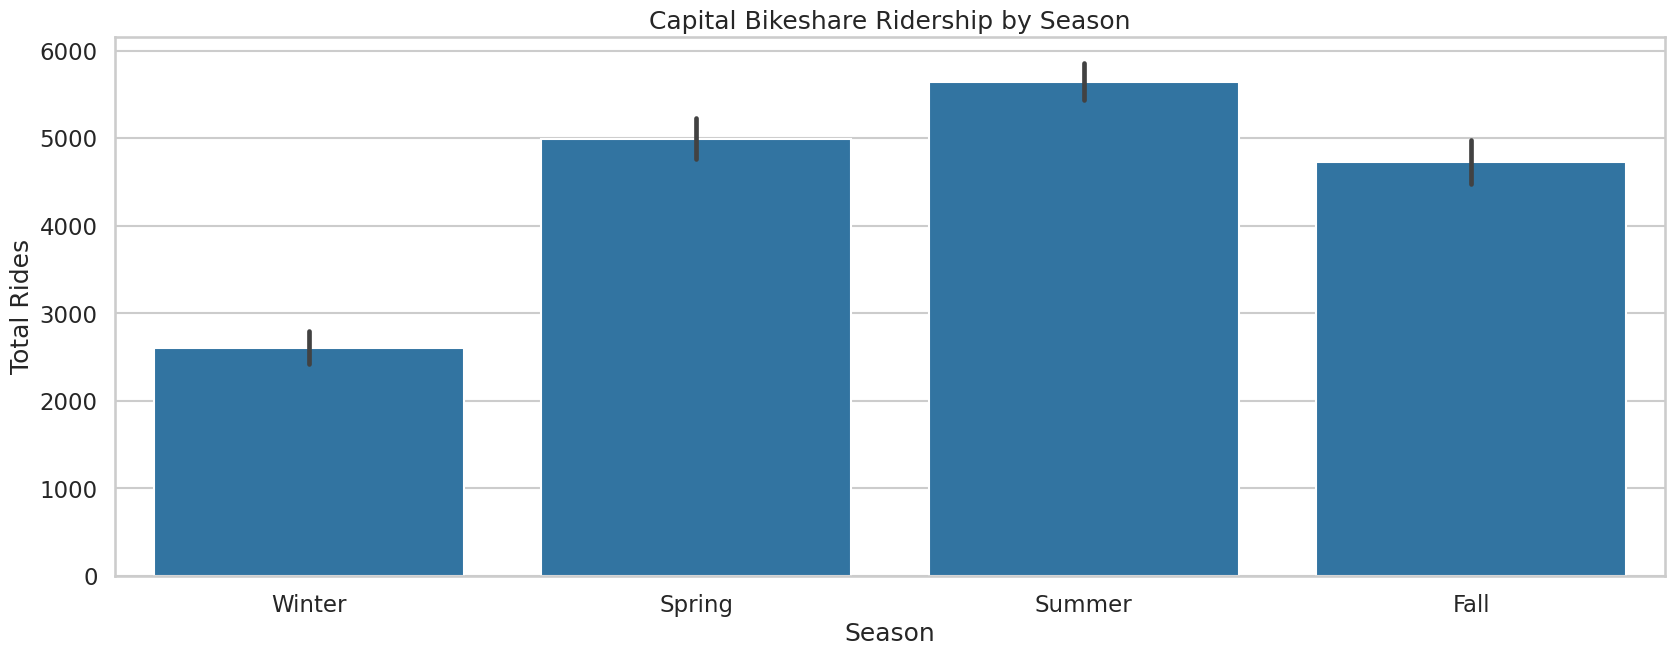

In [ ]:
fig, ax = plt.subplots()
sns.barplot(data=df[['season','total_rides']],
            x='season',
            y='total_rides',
            ax=ax)

plt.title('Capital Bikeshare Ridership by Season')
plt.ylabel('Total Rides')
plt.xlabel('Season')

tick_val=[0, 1, 2, 3]
tick_lab=['Winter', 'Spring', 'Summer', 'Fall']
plt.xticks(tick_val, tick_lab)

plt.show()

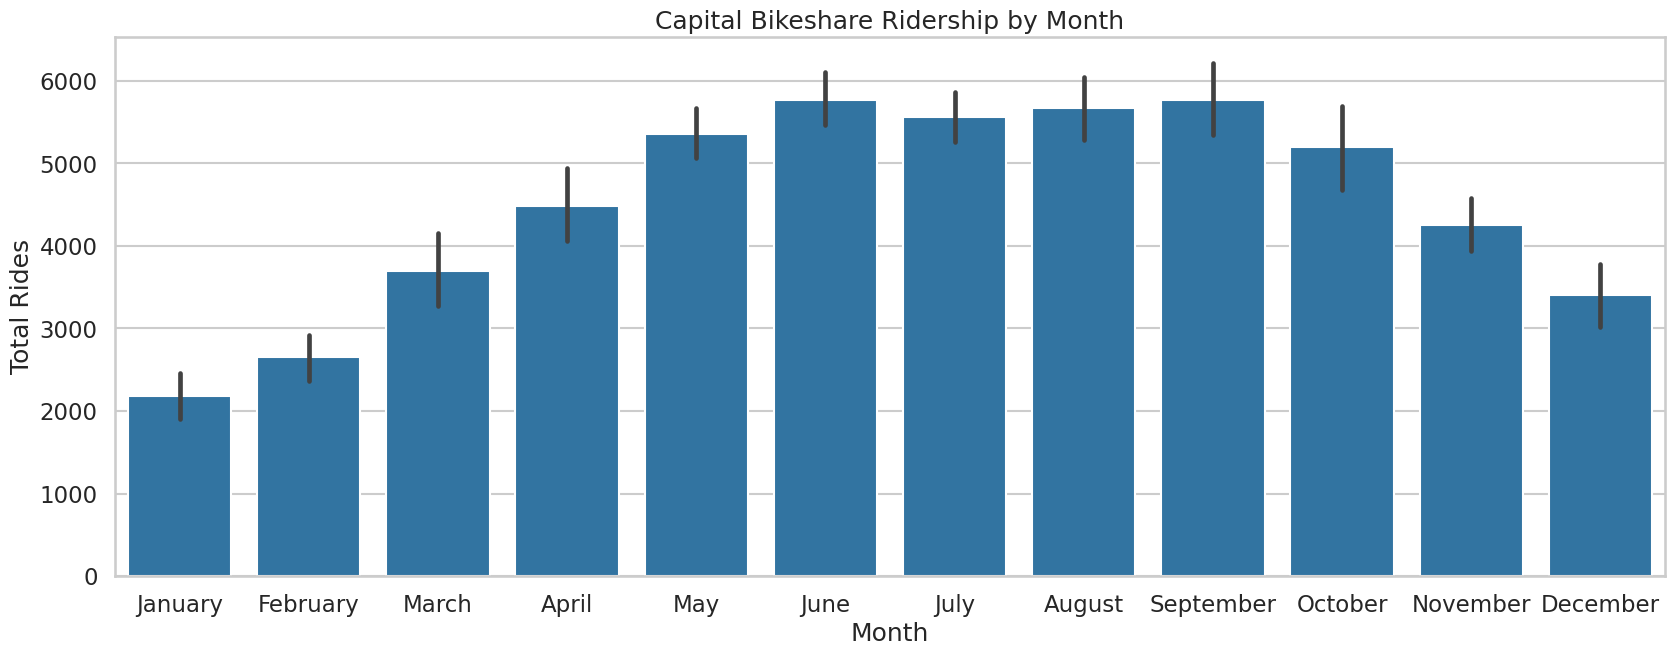

In [ ]:
fig, ax = plt.subplots()
sns.barplot(data=df[['month','total_rides']], x='month', y='total_rides', ax=ax)

plt.title('Capital Bikeshare Ridership by Month')
plt.ylabel('Total Rides')
plt.xlabel('Month')

tick_val=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
tick_lab=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.xticks(tick_val, tick_lab)

plt.show()

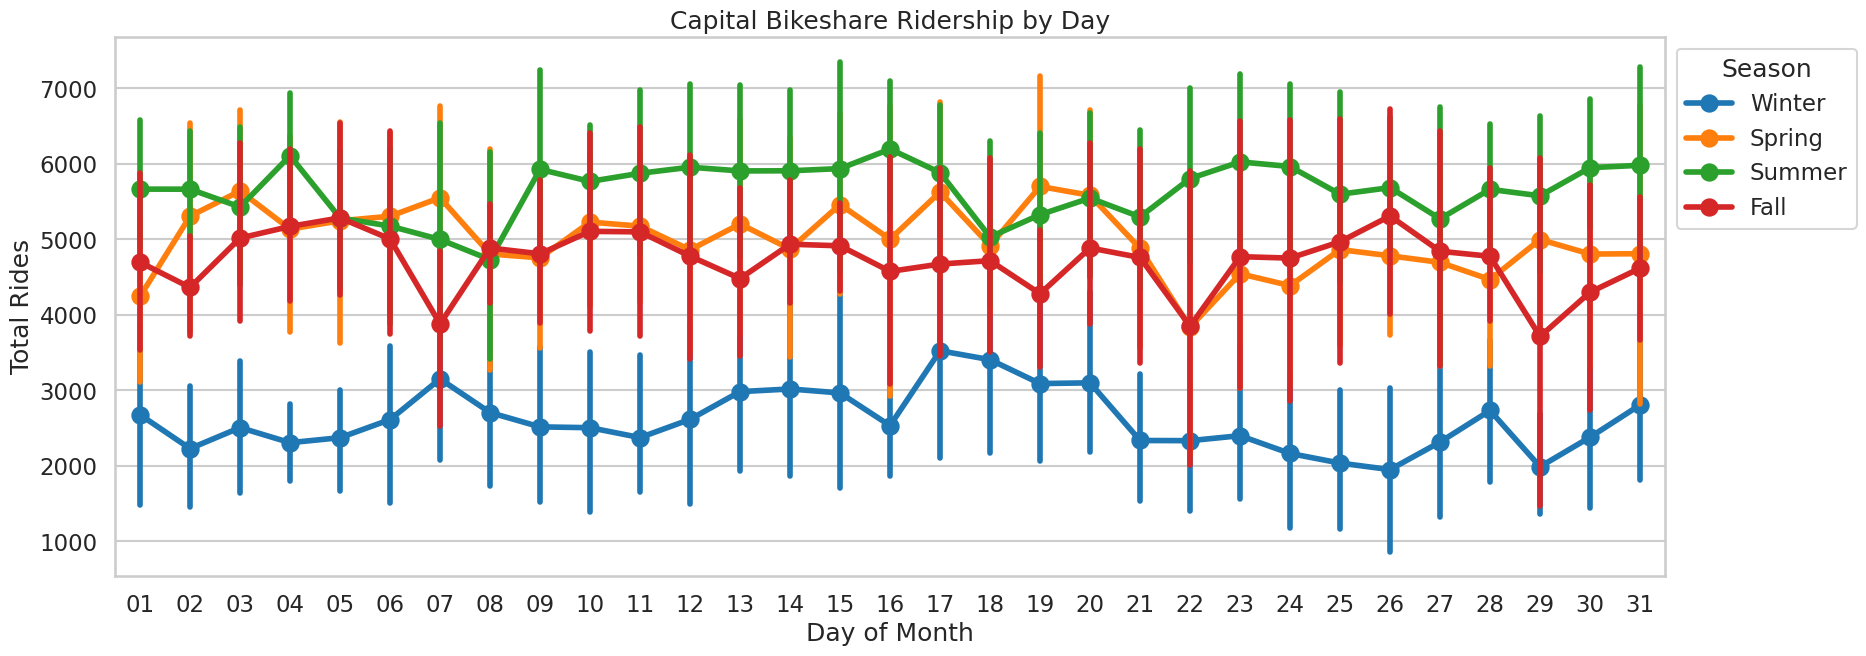

In [ ]:
df['day_of_month'] = df.datetime.str[-2:]
df.head()

fig, ax = plt.subplots()
sns.pointplot(data=df[['day_of_month', 'total_rides', 'season']],
              x='day_of_month',
              y='total_rides',
              hue='season',
              ax=ax)

plt.title('Capital Bikeshare Ridership by Day')
plt.ylabel('Total Rides')
plt.xlabel('Day of Month')

leg_handles = ax.get_legend_handles_labels()[0]
ax.legend(leg_handles, ['Winter', 'Spring', 'Summer', 'Fall'], title='Season', bbox_to_anchor=(1, 1), loc=2)

plt.show()

In [ ]:
ttest_ind(df['registered'], df['casual'])

TtestResult(statistic=np.float64(44.53675092663381), pvalue=np.float64(2.539407750032885e-274), df=np.float64(1460.0))

<Axes: >

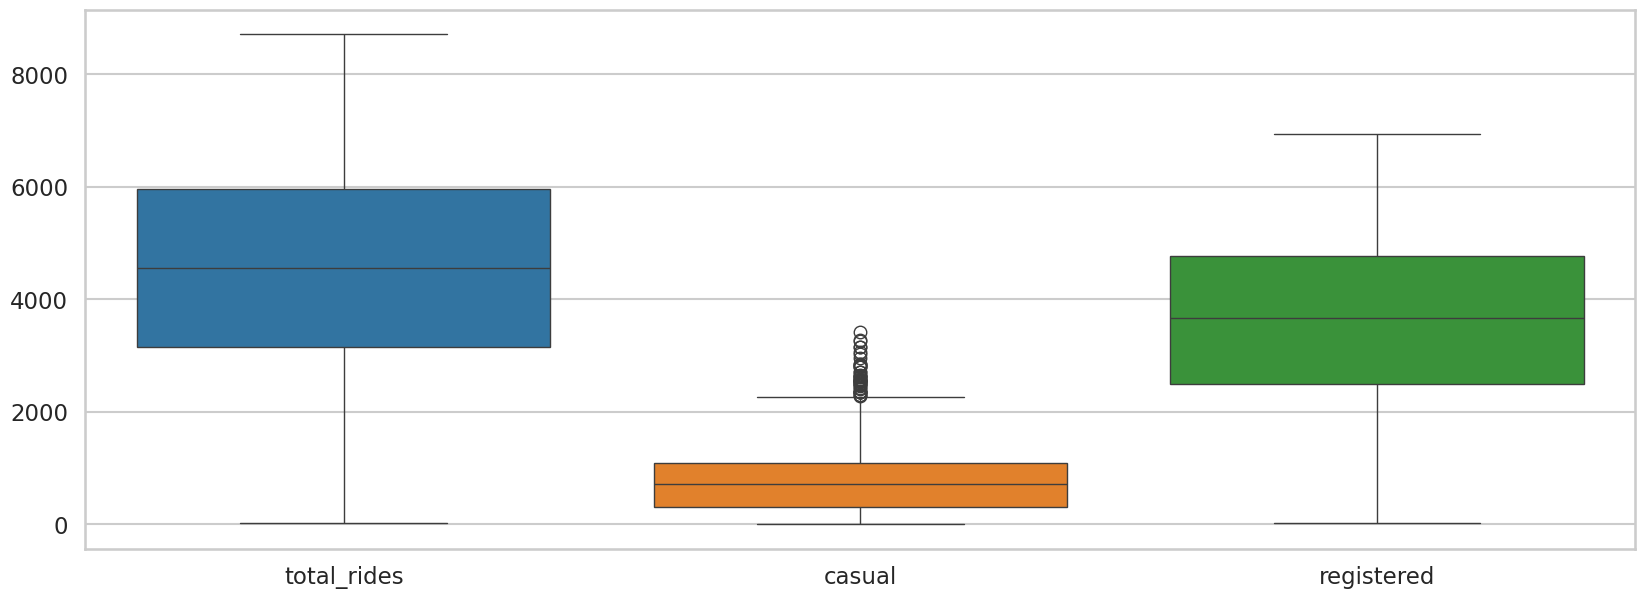

In [ ]:
fig = plt.subplot()
sns.boxplot(data=df[['total_rides', 'casual', 'registered']])

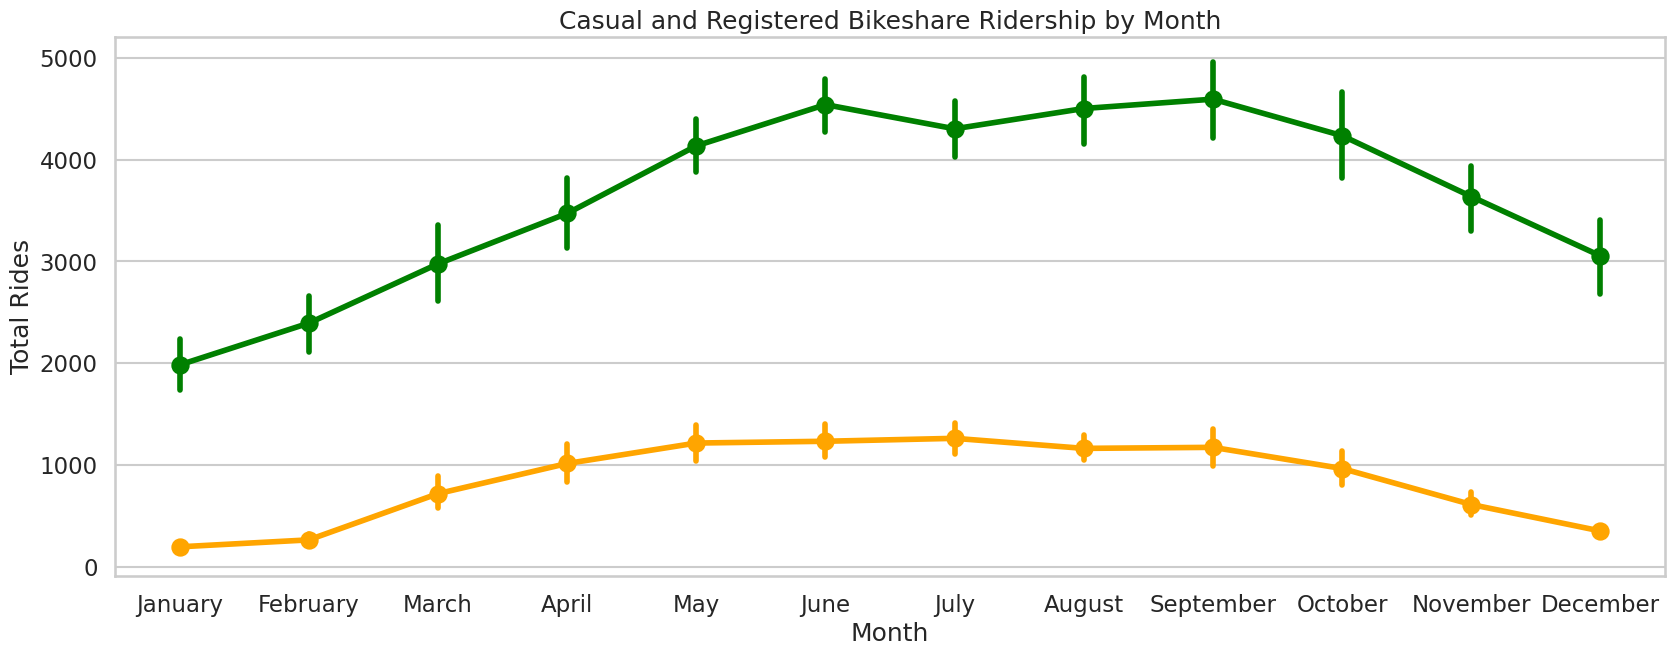

In [ ]:
fig, ax = plt.subplots()
sns.pointplot(data=df[['month', 'casual', 'registered']],
              x='month',
              y='casual',
              ax=ax,
              color='orange')

sns.pointplot(data=df[['month', 'casual', 'registered']],
              x='month',
              y='registered',
              ax=ax,
              color='green')

tick_val=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
tick_lab=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.xticks(tick_val, tick_lab)
plt.title('Casual and Registered Bikeshare Ridership by Month')
plt.ylabel('Total Rides')
plt.xlabel('Month')

plt.show()

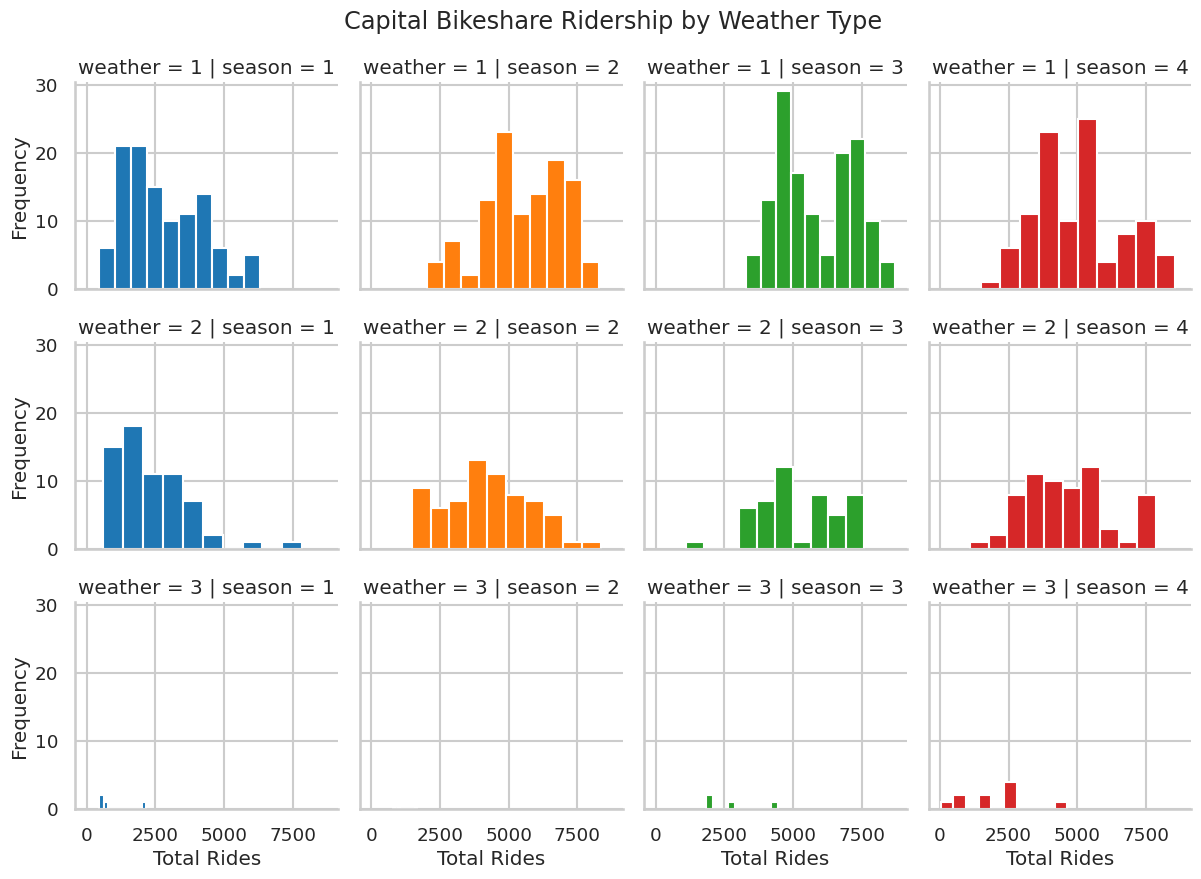

In [ ]:
plt.rcParams['figure.figsize'] = [10.0, 10.0]
sns.set_context('talk', font_scale=0.8)

g = sns.FacetGrid(data=df,
               col='season',
               row='weather',hue='season')
g.map(plt.hist,'total_rides')

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Capital Bikeshare Ridership by Weather Type')

g.set_xlabels('Total Rides')
g.set_ylabels('Frequency')

plt.show()